# 04 - Thực nghiệm tìm đặc trưng tốt (Feature Experiments / Ablation)

Mục tiêu theo đề bài: *chạy thực nghiệm tìm đặc trưng tốt giúp mô hình cải tiến*.

Notebook này tự đọc dữ liệu gốc, dựng lại từng phiên bản bộ đặc trưng và đo bằng **cùng 5-fold CV (seed 42)** với hai mô hình đại diện (Ridge - tuyến tính, Gradient Boosting - cây):

| Phiên bản | Nội dung |
|---|---|
| **A** | Baseline: dữ liệu đã làm sạch, **chưa** có đặc trưng mới |
| **B** | A + 7 đặc trưng mới (`TotalSF`, `TotalBaths`, `HouseAge`, `RemodAge`, `HasGarage`, `HasBsmt`, `HasFireplace`) |
| **C** | B + `MSSubClass` là categorical + `log1p` các biến liên tục lệch phải |
| **D** | C + mã hóa thứ tự (ordinal) cho các cột chất lượng |

Sau đó: (2) đóng góp từng đặc trưng mới (add-one / drop-one), (3) chọn đặc trưng bằng Lasso **bên trong** CV (không rò rỉ), (4) đặc trưng quan trọng, (5) lưu bộ đặc trưng tốt nhất cho notebook 02/03.

*Chạy mất khoảng vài phút.*

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingRegressor
warnings.filterwarnings("ignore")

train_raw = pd.read_csv("../data/train.csv")
test_raw = pd.read_csv("../data/test.csv")
os.makedirs("../results", exist_ok=True)
print("Train:", train_raw.shape, "| Test:", test_raw.shape)

Train: (1460, 81) | Test: (1459, 80)


## 1. Hàm làm sạch & dựng đặc trưng (giống notebook 01)

In [2]:
DROP_COLS = ["Alley", "PoolQC", "Fence", "MiscFeature"]
NONE_COLS = ["GarageType", "GarageFinish", "GarageQual", "GarageCond", "BsmtQual", "BsmtCond", "BsmtExposure",
             "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "MasVnrType"]
ZERO_COLS = ["GarageYrBlt", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea"]

def clean_data(train_raw, test_raw):
    train, test = train_raw.copy(), test_raw.copy()
    out = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)      # outlier theo De Cock
    train = train.loc[~out].reset_index(drop=True)
    train, test = train.drop(columns=DROP_COLS), test.drop(columns=DROP_COLS)
    for df in (train, test):
        for c in NONE_COLS: df[c] = df[c].fillna("None")
        for c in ZERO_COLS: df[c] = df[c].fillna(0)
    lot_med = train.groupby("Neighborhood")["LotFrontage"].median()
    for df in (train, test):
        df["LotFrontage"] = df["LotFrontage"].fillna(df["Neighborhood"].map(lot_med))
        df["LotFrontage"] = df["LotFrontage"].fillna(train["LotFrontage"].median())
    for c in [c for c in train.columns if not pd.api.types.is_numeric_dtype(train[c])]:
        m = train[c].mode()[0]
        for df in (train, test): df[c] = df[c].fillna(m)
    for c in test.select_dtypes(include=np.number).columns:
        med = train[c].median()
        for df in (train, test): df[c] = df[c].fillna(med)
    assert train.isnull().sum().sum() == 0 and test.isnull().sum().sum() == 0
    return train, test

NEW_FEATURES = {
    "TotalSF":      lambda d: d["TotalBsmtSF"] + d["1stFlrSF"] + d["2ndFlrSF"],
    "TotalBaths":   lambda d: d["FullBath"] + 0.5 * d["HalfBath"] + d["BsmtFullBath"] + 0.5 * d["BsmtHalfBath"],
    "HouseAge":     lambda d: (d["YrSold"] - d["YearBuilt"]).clip(lower=0),
    "RemodAge":     lambda d: (d["YrSold"] - d["YearRemodAdd"]).clip(lower=0),
    "HasGarage":    lambda d: (d["GarageArea"] > 0).astype(int),
    "HasBsmt":      lambda d: (d["TotalBsmtSF"] > 0).astype(int),
    "HasFireplace": lambda d: (d["Fireplaces"] > 0).astype(int),
}
ALL_NEW = list(NEW_FEATURES)

QUAL = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ORDINAL_MAPS = {
    **{c: QUAL for c in ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual",
                         "FireplaceQu", "GarageQual", "GarageCond"]},
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "LandSlope":    {"Sev": 1, "Mod": 2, "Gtl": 3},
    "LotShape":     {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "PavedDrive":   {"N": 0, "P": 1, "Y": 2},
    "CentralAir":   {"N": 0, "Y": 1},
    "Functional":   {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
}

def build_features(train, test, new_feats=(), msub_cat=False, log_skew=False, ordinal=False):
    y = np.log1p(train["SalePrice"]).reset_index(drop=True)
    n_train = len(train)
    f = pd.concat([train.drop(columns=["Id", "SalePrice"]), test.drop(columns=["Id"])], axis=0).reset_index(drop=True)
    for name in new_feats:
        f[name] = NEW_FEATURES[name](f)
    if msub_cat:
        f["MSSubClass"] = f["MSSubClass"].astype(str)
    if ordinal:
        for c, mp in ORDINAL_MAPS.items():
            f[c] = f[c].map(mp)
        assert f[list(ORDINAL_MAPS)].notna().all().all(), "Có giá trị chưa nằm trong bảng ordinal"
    if log_skew:
        num = f.select_dtypes(include=np.number)
        cont = [c for c in num.columns if num[c].nunique() > 20 and num[c].min() >= 0]
        sk = f[cont].skew()
        cols = sk[sk > 0.75].index.tolist()
        f[cols] = np.log1p(f[cols])
    cat = [c for c in f.columns if not pd.api.types.is_numeric_dtype(f[c])]
    f = pd.get_dummies(f, columns=cat, dtype=int)
    return f.iloc[:n_train].reset_index(drop=True), f.iloc[n_train:].reset_index(drop=True), y

train_c, test_c = clean_data(train_raw, test_raw)
print("Sau làm sạch:", train_c.shape, test_c.shape)

Sau làm sạch: (1458, 77) (1459, 76)


In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)   # cùng bộ fold với notebook 02 và 03

def make_ridge():
    return make_pipeline(RobustScaler(), RidgeCV(alphas=np.logspace(-1, 3, 30)))   # tự chọn alpha trong từng fold

def make_gbr():
    return GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.7,
                                     max_features=0.3, random_state=42)

def cv_rmse(model, X, y):
    s = -cross_val_score(model, X, y, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    return s.mean(), s.std()

## 2. So sánh các phiên bản bộ đặc trưng (A -> D)

In [4]:
VERSIONS = {
    "A. Baseline (không đặc trưng mới)":       dict(),
    "B. A + 7 đặc trưng mới":                  dict(new_feats=ALL_NEW),
    "C. B + MSSubClass cat + log-skew":        dict(new_feats=ALL_NEW, msub_cat=True, log_skew=True),
    "D. C + ordinal encoding":                 dict(new_feats=ALL_NEW, msub_cat=True, log_skew=True, ordinal=True),
}

rows, built = [], {}
for name, kw in VERSIONS.items():
    Xtr, Xte, y = build_features(train_c, test_c, **kw)
    built[name] = (Xtr, Xte, y)
    r_m, r_s = cv_rmse(make_ridge(), Xtr, y)
    g_m, g_s = cv_rmse(make_gbr(), Xtr, y)
    rows.append({"Phiên bản": name, "Số đặc trưng": Xtr.shape[1],
                 "Ridge RMSE": r_m, "Ridge std": r_s, "GBR RMSE": g_m, "GBR std": g_s})
    print(f"{name:40s} | n={Xtr.shape[1]:4d} | Ridge {r_m:.4f} (+/-{r_s:.4f}) | GBR {g_m:.4f} (+/-{g_s:.4f})")

ver_df = pd.DataFrame(rows)
base = ver_df.iloc[0]
ver_df["Ridge Δ% so với A"] = (ver_df["Ridge RMSE"] / base["Ridge RMSE"] - 1) * 100
ver_df["GBR Δ% so với A"] = (ver_df["GBR RMSE"] / base["GBR RMSE"] - 1) * 100
display(ver_df.round(4))

A. Baseline (không đặc trưng mới)        | n= 284 | Ridge 0.1150 (+/-0.0085) | GBR 0.1172 (+/-0.0092)
B. A + 7 đặc trưng mới                   | n= 291 | Ridge 0.1151 (+/-0.0085) | GBR 0.1148 (+/-0.0058)
C. B + MSSubClass cat + log-skew         | n= 306 | Ridge 0.1119 (+/-0.0082) | GBR 0.1165 (+/-0.0062)
D. C + ordinal encoding                  | n= 236 | Ridge 0.1128 (+/-0.0080) | GBR 0.1147 (+/-0.0062)


,Phiên bản,Số đặc trưng,Ridge RMSE,Ridge std,GBR RMSE,GBR std,Ridge Δ% so với A,GBR Δ% so với A
0,A. Baseline (không đặc trưng mới),284,0.1150,0.0085,0.1172,0.0092,0.0000,0.0000
1,B. A + 7 đặc trưng mới,291,0.1151,0.0085,0.1148,0.0058,0.0202,-2.0250
2,C. B + MSSubClass cat + log-skew,306,0.1119,0.0082,0.1165,0.0062,-2.6962,-0.6253
3,D. C + ordinal encoding,236,0.1128,0.0080,0.1147,0.0062,-1.9865,-2.0978


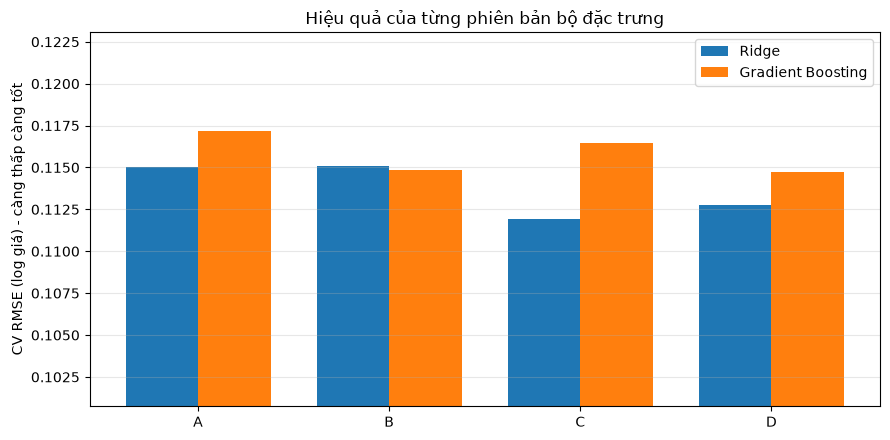

In [5]:
x = np.arange(len(ver_df)); w = 0.38
plt.figure(figsize=(9, 4.5))
plt.bar(x - w/2, ver_df["Ridge RMSE"], w, label="Ridge")
plt.bar(x + w/2, ver_df["GBR RMSE"], w, label="Gradient Boosting")
plt.xticks(x, [v.split(".")[0] for v in ver_df["Phiên bản"]])
lo = min(ver_df["Ridge RMSE"].min(), ver_df["GBR RMSE"].min())
plt.ylim(lo * 0.9, max(ver_df["Ridge RMSE"].max(), ver_df["GBR RMSE"].max()) * 1.05)
plt.ylabel("CV RMSE (log giá) - càng thấp càng tốt"); plt.title("Hiệu quả của từng phiên bản bộ đặc trưng")
plt.legend(); plt.grid(axis="y", alpha=.3); plt.tight_layout()
plt.savefig("../results/feature_versions.png", dpi=150); plt.show()

## 3. Đóng góp của từng đặc trưng mới
- **Add-one:** thêm *riêng* một đặc trưng vào baseline A.
- **Drop-one:** bỏ *riêng* một đặc trưng khỏi B (đủ 7 đặc trưng).

Δ < 0 nghĩa là RMSE giảm (đặc trưng có ích). Dùng Ridge để chạy nhanh.

In [6]:
XA, _, yA = built["A. Baseline (không đặc trưng mới)"]
rmse_A, _ = cv_rmse(make_ridge(), XA, yA)
XB, _, yB = built["B. A + 7 đặc trưng mới"]
rmse_B, _ = cv_rmse(make_ridge(), XB, yB)

contrib = []
for feat in ALL_NEW:
    Xa, _, ya = build_features(train_c, test_c, new_feats=[feat])
    add_r, _ = cv_rmse(make_ridge(), Xa, ya)
    Xd, _, yd = build_features(train_c, test_c, new_feats=[f for f in ALL_NEW if f != feat])
    drop_r, _ = cv_rmse(make_ridge(), Xd, yd)
    contrib.append({"Đặc trưng": feat,
                    "Add-one: RMSE": add_r, "Add-one Δ so với A": add_r - rmse_A,
                    "Drop-one: RMSE": drop_r, "Drop-one Δ so với B": drop_r - rmse_B})
contrib_df = pd.DataFrame(contrib).sort_values("Add-one Δ so với A").reset_index(drop=True)
print(f"RMSE Ridge: A = {rmse_A:.4f} | B = {rmse_B:.4f}")
display(contrib_df.round(5))

# Tương quan của đặc trưng mới với log giá (trên tập train đã làm sạch)
feat_tmp = pd.DataFrame({k: fn(train_c) for k, fn in NEW_FEATURES.items()})
print("\nTương quan với log(SalePrice):")
print(feat_tmp.corrwith(np.log1p(train_c["SalePrice"])).sort_values(ascending=False).round(3))

RMSE Ridge: A = 0.1150 | B = 0.1151


,Đặc trưng,Add-one: RMSE,Add-one Δ so với A,Drop-one: RMSE,Drop-one Δ so với B
0,TotalSF,0.11500,-0.00004,0.11511,0.00005
1,RemodAge,0.11504,-0.00000,0.11507,0.00000
2,HasGarage,0.11504,0.00000,0.11506,-0.00000
3,HasBsmt,0.11504,0.00000,0.11506,-0.00000
4,HasFireplace,0.11504,0.00000,0.11506,-0.00000
5,HouseAge,0.11506,0.00002,0.11505,-0.00002
6,TotalBaths,0.11509,0.00005,0.11486,-0.00020



Tương quan với log(SalePrice):
TotalSF         0.825
TotalBaths      0.677
HasFireplace    0.510
HasGarage       0.323
HasBsmt         0.200
RemodAge       -0.569
HouseAge       -0.588
dtype: float64


## 4. Chọn đặc trưng bằng Lasso (bên trong cross-validation)
`SelectFromModel(Lasso)` nằm **trong pipeline** nên việc chọn đặc trưng chỉ dùng dữ liệu train của từng fold -> điểm CV không bị rò rỉ.

In [7]:
X_D, _, y_D = built["D. C + ordinal encoding"]
sel_rows = [{"Cấu hình": "Không chọn (D, Ridge)", "Số đặc trưng giữ": X_D.shape[1], "Ridge RMSE": cv_rmse(make_ridge(), X_D, y_D)[0]}]
for a in [0.0003, 0.001, 0.003, 0.01]:
    pipe = make_pipeline(RobustScaler(), SelectFromModel(Lasso(alpha=a, max_iter=50000)),
                         RidgeCV(alphas=np.logspace(-1, 3, 30)))
    m, s = cv_rmse(pipe, X_D, y_D)
    n_keep = int(pipe.fit(X_D, y_D).named_steps["selectfrommodel"].get_support().sum())
    sel_rows.append({"Cấu hình": f"Lasso chọn đặc trưng (alpha={a})", "Số đặc trưng giữ": n_keep, "Ridge RMSE": m})
sel_df = pd.DataFrame(sel_rows)
display(sel_df.round(4))

,Cấu hình,Số đặc trưng giữ,Ridge RMSE
0,"Không chọn (D, Ridge)",236,0.1128
1,Lasso chọn đặc trưng (alpha=0.0003),115,0.1137
2,Lasso chọn đặc trưng (alpha=0.001),75,0.1114
3,Lasso chọn đặc trưng (alpha=0.003),43,0.1178
4,Lasso chọn đặc trưng (alpha=0.01),26,0.1249


## 5. Chọn phiên bản tốt nhất & lưu dữ liệu

In [8]:
ver_df["Điểm TB (Ridge, GBR)"] = (ver_df["Ridge RMSE"] + ver_df["GBR RMSE"]) / 2
best_idx = ver_df["Điểm TB (Ridge, GBR)"].idxmin()
best_name = ver_df.loc[best_idx, "Phiên bản"]
print("=> Phiên bản tốt nhất:", best_name)
print(f"   Ridge: {base['Ridge RMSE']:.4f} -> {ver_df.loc[best_idx, 'Ridge RMSE']:.4f} ({ver_df.loc[best_idx, 'Ridge Δ% so với A']:+.1f}%)")
print(f"   GBR  : {base['GBR RMSE']:.4f} -> {ver_df.loc[best_idx, 'GBR RMSE']:.4f} ({ver_df.loc[best_idx, 'GBR Δ% so với A']:+.1f}%)")

X_tr_best, X_te_best, y_best = built[best_name]
X_tr_best.to_csv("../data/X_train_best.csv", index=False)
X_te_best.to_csv("../data/X_test_best.csv", index=False)
print("Đã lưu ../data/X_train_best.csv, X_test_best.csv  ->  đặt FEATURE_SET = 'best' ở notebook 02 và 03 để dùng.")

# Kiểm tra y khớp với y_train_clean.csv của notebook 01
if os.path.exists("../data/y_train_clean.csv"):
    y_saved = pd.read_csv("../data/y_train_clean.csv")["SalePrice"].values
    print("y khớp notebook 01:", np.allclose(y_saved, y_best.values))

ver_df.to_csv("../results/feature_versions.csv", index=False)
contrib_df.to_csv("../results/feature_contribution.csv", index=False)
sel_df.to_csv("../results/feature_selection.csv", index=False)

=> Phiên bản tốt nhất: D. C + ordinal encoding
   Ridge: 0.1150 -> 0.1128 (-2.0%)
   GBR  : 0.1172 -> 0.1147 (-2.1%)
Đã lưu ../data/X_train_best.csv, X_test_best.csv  ->  đặt FEATURE_SET = 'best' ở notebook 02 và 03 để dùng.
y khớp notebook 01: True


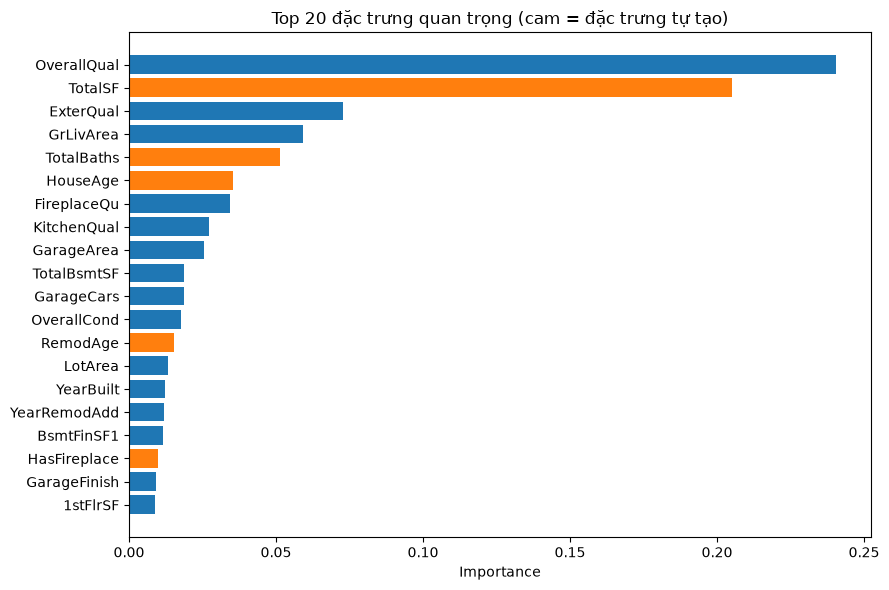

In [9]:
# Đặc trưng quan trọng nhất trên bộ tốt nhất (GBR) - đặc trưng mới được tô màu cam
gbr = make_gbr().fit(X_tr_best, y_best)
imp = pd.Series(gbr.feature_importances_, index=X_tr_best.columns).sort_values(ascending=False).head(20)[::-1]
colors = ["tab:orange" if i in ALL_NEW else "tab:blue" for i in imp.index]
plt.figure(figsize=(9, 6)); plt.barh(imp.index, imp.values, color=colors)
plt.title("Top 20 đặc trưng quan trọng (cam = đặc trưng tự tạo)"); plt.xlabel("Importance")
plt.tight_layout(); plt.savefig("../results/feature_importance_best.png", dpi=150); plt.show()

## Cách đọc kết quả để viết báo cáo
1. Bảng ở mục 2: phiên bản nào làm RMSE giảm nhiều nhất so với A, cho cả mô hình tuyến tính lẫn cây.
2. Bảng ở mục 3: đặc trưng nào thực sự có ích (Δ âm rõ rệt so với độ lệch chuẩn giữa các fold), đặc trưng nào gần như không đổi.
3. Mục 4: giữ ít đặc trưng hơn có làm RMSE tệ đi không? (đánh đổi độ đơn giản / chính xác).
4. Biểu đồ importance: đặc trưng tự tạo có nằm trong top không (ví dụ `TotalSF`).

*Lưu ý:* chênh lệch nhỏ hơn độ lệch chuẩn giữa các fold nên được xem là **không có ý nghĩa rõ ràng**.